# ◈ ARCANA — Stage 6 (v3): Portfolio Construction

Pair-based backtest using rolling walk-forward signals.
Hedge ratios update each year to match the training window.

**Entry:** Z > +2 → long spread (long A, short B)
**Exit:**  |Z| < 0.5 → close
**Stop:**  |Z| > 4.0 → stop loss
---

## 0 · Imports & Config

In [33]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#0d0f14','axes.facecolor':'#0d0f14','axes.edgecolor':'#2a2d35',
    'axes.labelcolor':'#8b8fa8','axes.titlecolor':'#e2e4ed','axes.titlesize':13,
    'axes.labelsize':11,'axes.grid':True,'grid.color':'#1e2029','grid.linewidth':0.6,
    'xtick.color':'#555870','ytick.color':'#555870','xtick.labelsize':9,'ytick.labelsize':9,
    'text.color':'#e2e4ed','legend.facecolor':'#12141a','legend.edgecolor':'#2a2d35',
    'legend.fontsize':9,'lines.linewidth':1.4,'font.family':'monospace',
})
C_GOLD='#c9a84c';C_TEAL='#3ec9b0';C_BLUE='#4f8ef7'
C_RED='#e05c6b';C_PURPLE='#9b7fe8';C_GREY='#555870';C_WHITE='#e2e4ed'
REGIME_COLORS={0:C_TEAL,1:C_GOLD,2:C_RED}

STAGE2_DIR  = r'C:\Arbion Research\Stage 2 feature engineering'
STAGE3_DIR  = r'C:\Arbion Research\Stage 3 HMM regime engine'
STAGE4A_DIR = r'C:\Arbion Research\Stage 4A stat arb engine'
STAGE5_DIR  = r'C:\Arbion Research\Stage 5 signal blending'
OUTPUT_DIR  = r'C:\Arbion Research\Stage 6 portfolio construction'

START_DATE = '2010-01-01'
END_DATE   = '2025-12-31'

MOM_WINDOW_SHORT = 10    # days — short-term momentum
MOM_WINDOW_LONG  = 60    # days — long-term trend
MOM_THRESHOLD    = 0.02  # 2% spread move = strong momentum

ZSCORE_ENTRY    = 2.0
ZSCORE_EXIT     = 0.5
ZSCORE_STOP     = 4.0
WEIGHT_PER_PAIR = 0.1
MAX_PAIRS_OPEN  = 10
REGIME_SCALE    = {0:1.0,1:0.7,2:0.0}

os.makedirs(OUTPUT_DIR,exist_ok=True)
print('✓ Config loaded')
print(f'  Entry/Exit/Stop : {ZSCORE_ENTRY}/{ZSCORE_EXIT}/{ZSCORE_STOP}')
print(f'  Weight per pair : {WEIGHT_PER_PAIR}')
print(f'  Max pairs open  : {MAX_PAIRS_OPEN}')

✓ Config loaded
  Entry/Exit/Stop : 2.0/0.5/4.0
  Weight per pair : 0.1
  Max pairs open  : 10


---
## Step 1 · Load Inputs

In [34]:
# Blended signal
blended = pd.read_csv(os.path.join(STAGE5_DIR,'blended_signal.csv'),
                      index_col=0,parse_dates=True)
blended = blended.loc[START_DATE:END_DATE]

# Raw Z-scores for entry/exit logic
zscore_raw = pd.read_csv(os.path.join(STAGE4A_DIR,'zscore_signals_rolling.csv'),
                          index_col=0,parse_dates=True)
zscore_raw = zscore_raw.reindex(blended.index)

# Hedge ratios — per pair per year (rolling)
hedge_meta = pd.read_csv(os.path.join(STAGE4A_DIR,'hedge_ratios_rolling.csv'))
# Average h per pair across years as fallback
hedge_avg  = hedge_meta.groupby('pair')['h'].mean()

# Returns
returns = pd.read_csv(os.path.join(STAGE2_DIR,'features_returns.csv'),
                      index_col=0,parse_dates=True)
returns = returns.reindex(blended.index)

# Regime labels
regime_labels = pd.read_csv(os.path.join(STAGE3_DIR,'regime_labels_weekly.csv'),
                             index_col=0,parse_dates=True).squeeze()
regime_labels = regime_labels.reindex(blended.index,method='ffill')

common_dates = blended.index
elite_pairs  = blended.columns.tolist()

print('✓ Inputs loaded')
print(f'  Blended signal : {blended.shape}')
print(f'  Date range     : {common_dates[0].date()} to {common_dates[-1].date()}')
print(f'  Elite pairs    : {elite_pairs}')
print(f'  Returns shape  : {returns.shape}')

✓ Inputs loaded
  Blended signal : (4023, 194)
  Date range     : 2010-01-05 to 2025-12-31
  Elite pairs    : ['DHR_HCA', 'CVX_KMI', 'BKNG_TSLA', 'COP_MPC', 'NKE_TSLA', 'NKE_ORLY', 'MDLZ_PM', 'AZO_TSLA', 'BA_HON', 'CTSH_TXN', 'SBUX_TSLA', 'AMGN_MRK', 'BA_GE', 'FDX_WM', 'BA_UPS', 'EMR_WM', 'ORLY_TSLA', 'BA_UNP', 'BA_MMM', 'BA_LMT', 'ABBV_GILD', 'ABBV_TMO', 'ABBV_CVS', 'C_GS', 'ORLY_SBUX', 'KO_MO', 'AMAT_MU', 'RTX_WM', 'IBM_NVDA', 'CI_TMO', 'CL_MDLZ', 'COP_EOG', 'MPC_VLO', 'CVX_MPC', 'CL_COST', 'AVGO_CRM', 'AVGO_MSFT', 'EMR_ETN', 'COST_PG', 'ABBV_UNH', 'DHR_SYK', 'ABBV_SYK', 'ABBV_ABT', 'CTSH_QCOM', 'PSX_VLO', 'MSFT_NVDA', 'BAC_BLK', 'CRM_QCOM', 'BLK_JPM', 'ABBV_CI', 'AMAT_TXN', 'GILD_HCA', 'BAC_JPM', 'COF_USB', 'KO_PEP', 'CRM_CTSH', 'HON_LMT', 'PNC_WFC', 'SCHW_USB', 'COF_MS', 'CVS_SYK', 'ABT_CVS', 'C_ICE', 'CMCSA_META', 'ABBV_AMGN', 'ABT_HCA', 'SCHW_WFC', 'PNC_SCHW', 'USB_WFC', 'ACN_IBM', 'MS_USB', 'AZO_ORLY', 'ACN_ADBE', 'CHTR_CMCSA', 'HON_WM', 'KHC_WMT', 'AZO_SBUX', 'MO_PEP', 'ORLY_TJ

---
## Step 2 · Parse Pair Tickers + Hedge Ratios

In [35]:
pair_info = {}

for pair in elite_pairs:
    parts = pair.split('_')
    if len(parts) == 2:
        tA, tB = parts[0], parts[1]
    else:
        found = False
        for i in range(1,len(parts)):
            tA = '_'.join(parts[:i])
            tB = '_'.join(parts[i:])
            if tA in returns.columns and tB in returns.columns:
                found = True; break
        if not found:
            tA, tB = parts[0], parts[-1]

    # Use average hedge ratio across years
    h = float(hedge_avg.loc[pair]) if pair in hedge_avg.index else 1.0
    pair_info[pair] = {'tA':tA,'tB':tB,'h':h}
    print(f'  {pair:<22} A={tA:<8} B={tB:<8} h={h:.4f}')

print(f'\n✓ {len(pair_info)} pairs parsed')
missing=[]
for pair,info in pair_info.items():
    for t in [info['tA'],info['tB']]:
        if t not in returns.columns:
            missing.append((pair,t))
if missing:
    print(f'\n⚠ Missing tickers:')
    for pair,t in missing: print(f'  {pair} — {t} not in returns')
else:
    print('  All tickers found in returns ✓')

  DHR_HCA                A=DHR      B=HCA      h=0.3213
  CVX_KMI                A=CVX      B=KMI      h=0.3805
  BKNG_TSLA              A=BKNG     B=TSLA     h=1.2940
  COP_MPC                A=COP      B=MPC      h=0.3035
  NKE_TSLA               A=NKE      B=TSLA     h=0.6116
  NKE_ORLY               A=NKE      B=ORLY     h=0.5413
  MDLZ_PM                A=MDLZ     B=PM       h=0.4197
  AZO_TSLA               A=AZO      B=TSLA     h=0.9240
  BA_HON                 A=BA       B=HON      h=0.4479
  CTSH_TXN               A=CTSH     B=TXN      h=1.0398
  SBUX_TSLA              A=SBUX     B=TSLA     h=1.2591
  AMGN_MRK               A=AMGN     B=MRK      h=1.4526
  BA_GE                  A=BA       B=GE       h=0.5149
  FDX_WM                 A=FDX      B=WM       h=0.8744
  BA_UPS                 A=BA       B=UPS      h=0.6856
  EMR_WM                 A=EMR      B=WM       h=1.1376
  ORLY_TSLA              A=ORLY     B=TSLA     h=1.0655
  BA_UNP                 A=BA       B=UNP      h

---
## Step 3 · Build Year-Aware Hedge Ratio Lookup
For each day, use the hedge ratio from that trade year.

In [36]:
# Build (pair, year) → h lookup for time-varying hedge ratios
pair_year_h = {}
for _,row in hedge_meta.iterrows():
    pair_year_h[(row['pair'],int(row['trade_year']))] = float(row['h'])

print('✓ Year-aware hedge ratios built')
print(f'  Total entries: {len(pair_year_h)}')
print(f'\nSample (pair, year) → h:')
for k,v in list(pair_year_h.items())[:8]:
    print(f'  {k[0]:<22} {k[1]} → h={v:.4f}')

✓ Year-aware hedge ratios built
  Total entries: 260

Sample (pair, year) → h:
  DHR_HCA                2013 → h=0.3213
  CVX_KMI                2013 → h=0.3805
  BKNG_TSLA              2013 → h=1.2940
  COP_MPC                2013 → h=0.2599
  NKE_TSLA               2013 → h=0.6116
  NKE_ORLY               2013 → h=0.5413
  MDLZ_PM                2013 → h=0.5539
  AZO_TSLA               2013 → h=0.9240


---
## Step 4 · Walk-Forward Backtest

In [37]:
# ── Dynamic vol targeting ──────────────────────────────────────────────────
VOL_TARGET       = 0.10          # 10% annual target
WEIGHT_PER_PAIR  = 0.10          # base weight per pair
MAX_PAIRS_OPEN   = 10
ZSCORE_ENTRY     = 2.0
ZSCORE_EXIT      = 0.5
ZSCORE_STOP      = 4.0
VOL_LOOKBACK     = 60            # days to estimate realised vol
REGIME_SCALE     = {0:1.0, 1:0.7, 2:0.0}

MOM_WINDOW_SHORT = 10
MOM_WINDOW_LONG  = 60
MOM_STRENGTH_THR = 0.8

open_positions = {}
port_returns   = pd.Series(0.0, index=common_dates)
weight_log     = pd.DataFrame(0.0, index=common_dates, columns=[
    p for p in elite_pairs
    if pair_info[p]['tA'] in returns.columns
    and pair_info[p]['tB'] in returns.columns
])

valid_pairs = [p for p in elite_pairs
               if pair_info[p]['tA'] in returns.columns
               and pair_info[p]['tB'] in returns.columns]

mode_log      = []
realised_vols = []   # track daily vol estimates

print(f'  Valid pairs  : {len(valid_pairs)}')
print(f'  Vol target   : {VOL_TARGET:.0%}')
print(f'  Base weight  : {WEIGHT_PER_PAIR}')

for i, date in enumerate(common_dates):
    if i == 0:
        continue

    # ── Dynamic vol scalar ────────────────────────────────────────────────
    # Estimate realised portfolio vol from recent history
    if i >= VOL_LOOKBACK + 1:
        recent_rets = port_returns.iloc[i-VOL_LOOKBACK:i]
        recent_vol  = recent_rets.std() * np.sqrt(252)
        # Scale weight to hit vol target
        # Avoid division by zero and cap leverage at 3×
        if recent_vol > 0.001:
            vol_scalar = min(VOL_TARGET / recent_vol, 3.0)
        else:
            vol_scalar = 1.0
    else:
        vol_scalar = 1.0   # no scaling until we have enough history

    realised_vols.append({'date': date, 'vol_scalar': vol_scalar})

    trade_year = date.year
    regime     = int(regime_labels.loc[date]) \
                 if not pd.isna(regime_labels.loc[date]) else 1
    r_scale    = REGIME_SCALE[regime]
    day_return = 0.0

    for pair in valid_pairs:
        tA = pair_info[pair]['tA']
        tB = pair_info[pair]['tB']
        h  = pair_year_h.get((pair, trade_year),
             pair_year_h.get((pair, trade_year - 1),
             pair_info[pair]['h']))

        if pair not in zscore_raw.columns:
            continue
        z = zscore_raw.loc[date, pair] \
            if date in zscore_raw.index else np.nan
        if pd.isna(z):
            if pair in open_positions:
                del open_positions[pair]
            continue

        ret_A = returns.loc[date, tA] \
                if tA in returns.columns and date in returns.index else np.nan
        ret_B = returns.loc[date, tB] \
                if tB in returns.columns and date in returns.index else np.nan
        if pd.isna(ret_A) or pd.isna(ret_B):
            continue

        # ── Momentum strength ─────────────────────────────────────────────
        z_series = zscore_raw[pair].loc[:date].dropna() \
                   if pair in zscore_raw.columns else pd.Series(dtype=float)

        momentum_mode = False
        mom_short     = 0.0
        if len(z_series) >= MOM_WINDOW_LONG:
            z_short_ago   = z_series.iloc[-MOM_WINDOW_SHORT]
            z_long_ago    = z_series.iloc[-MOM_WINDOW_LONG]
            mom_short     = z_series.iloc[-1] - z_short_ago
            mom_long      = z_series.iloc[-1] - z_long_ago
            momentum_mode = (abs(mom_short) > MOM_STRENGTH_THR and
                             np.sign(mom_short) == np.sign(mom_long))

        # ── Position management ───────────────────────────────────────────
        if pair in open_positions:
            direction = open_positions[pair]
            if abs(z) < ZSCORE_EXIT:
                del open_positions[pair]
                direction = 0
            elif abs(z) > ZSCORE_STOP:
                del open_positions[pair]
                direction = -direction
        else:
            direction = 0
            if r_scale > 0 and len(open_positions) < MAX_PAIRS_OPEN:
                if z > ZSCORE_ENTRY:
                    direction = +1
                    open_positions[pair] = direction
                    mode_log.append({'date': date, 'pair': pair,
                                     'z': z, 'momentum_mode': momentum_mode})
                elif z < -ZSCORE_ENTRY:
                    direction = -1
                    open_positions[pair] = direction
                    mode_log.append({'date': date, 'pair': pair,
                                     'z': z, 'momentum_mode': momentum_mode})

        # ── Compute return with dynamic vol scaling ───────────────────────
        if direction != 0:
            w        = WEIGHT_PER_PAIR * vol_scalar * r_scale
            pair_ret = direction * (ret_A - h * ret_B) / (1 + abs(h))
            day_return += pair_ret * w
            if pair in weight_log.columns:
                weight_log.loc[date, pair] = direction * w

    port_returns.loc[date] = day_return

# ── Summary ───────────────────────────────────────────────────────────────
mode_df    = pd.DataFrame(mode_log)
gross_exp  = weight_log.abs().sum(axis=1)
open_count = (weight_log.abs() > 0).sum(axis=1)
vol_df     = pd.DataFrame(realised_vols).set_index('date')

print(f'\n✓ Backtest complete')
print(f'  Trading days      : {(port_returns != 0).sum()}')
print(f'  Avg open pairs    : {open_count.mean():.1f}')
print(f'  Avg gross exposure: {gross_exp.mean()*100:.1f}%')
print(f'  Max gross exposure: {gross_exp.max()*100:.1f}%')
print(f'  Avg vol scalar    : {vol_df["vol_scalar"].mean():.2f}x')
print(f'  Max vol scalar    : {vol_df["vol_scalar"].max():.2f}x')

if len(mode_df) > 0:
    mom   = mode_df['momentum_mode'].sum()
    total = len(mode_df)
    print(f'\n  Entry mode: Momentum {mom/total*100:.1f}%  '
          f'Reversion {(total-mom)/total*100:.1f}%')

  Valid pairs  : 194
  Vol target   : 10%
  Base weight  : 0.1

✓ Backtest complete
  Trading days      : 2655
  Avg open pairs    : 5.4
  Avg gross exposure: 72.3%
  Max gross exposure: 300.0%
  Avg vol scalar    : 1.46x
  Max vol scalar    : 3.00x

  Entry mode: Momentum 63.3%  Reversion 36.7%


---
## Step 5 · Performance Statistics

In [38]:
port_ret = port_returns.copy()
cum_ret  = (1+port_ret).cumprod()

spy_ret = pd.read_csv(os.path.join(STAGE2_DIR,'features_returns.csv'),
                       index_col=0,parse_dates=True)['SPY'].reindex(common_dates)
spy_cum = (1+spy_ret).cumprod()

ann_ret  = cum_ret.iloc[-1]**(252/len(port_ret))-1
ann_vol  = port_ret.std()*np.sqrt(252)
sharpe   = ann_ret/ann_vol if ann_vol>0 else 0
running_max=cum_ret.cummax()
drawdown=(cum_ret-running_max)/running_max
max_dd   = drawdown.min()
calmar   = ann_ret/abs(max_dd) if max_dd!=0 else 0
port_beta= port_ret.cov(spy_ret)/spy_ret.var() if spy_ret.var()>0 else 0
win_rate = (port_ret[port_ret!=0]>0).mean()

port_ret.to_csv(os.path.join(OUTPUT_DIR,'portfolio_returns.csv'))
weight_log.to_csv(os.path.join(OUTPUT_DIR,'portfolio_weights.csv'))
pd.Series({'ann_return':ann_ret,'ann_vol':ann_vol,'sharpe':sharpe,
           'max_drawdown':max_dd,'calmar':calmar,'beta':port_beta,
           'win_rate':win_rate}).to_csv(os.path.join(OUTPUT_DIR,'portfolio_stats.csv'))

print('='*52)
print('  PORTFOLIO PERFORMANCE SUMMARY')
print('='*52)
print(f'  Ann. return   : {ann_ret*100:>8.2f}%')
print(f'  Ann. vol      : {ann_vol*100:>8.2f}%')
print(f'  Sharpe ratio  : {sharpe:>8.3f}')
print(f'  Max drawdown  : {max_dd*100:>8.2f}%')
print(f'  Calmar ratio  : {calmar:>8.3f}')
print(f'  Portfolio beta: {port_beta:>8.3f}')
print(f'  Win rate      : {win_rate*100:>8.1f}%')
print('='*52)

regime_al=regime_labels.reindex(port_ret.index,method='ffill')
print(f'\n{"Year":<6} {"Return":>8} {"Vol":>8} {"Sharpe":>8} {"Regime"}')
print('-'*45)
for year in range(2013,2026):
    mask=port_ret.index.year==year
    if not mask.any(): continue
    r=port_ret[mask]
    ar=r.mean()*252*100; av=r.std()*np.sqrt(252)*100
    sr=r.mean()/r.std()*np.sqrt(252) if r.std()>0 else 0
    rl=regime_al[mask].dropna()
    rn={0:'Bull',1:'Neutral',2:'Crisis'}.get(int(rl.mode()[0]),'?') if len(rl)>0 else '?'
    print(f'{year:<6} {ar:>7.2f}% {av:>7.2f}% {sr:>8.3f}  {rn}')

  PORTFOLIO PERFORMANCE SUMMARY
  Ann. return   :    17.39%
  Ann. vol      :     6.23%
  Sharpe ratio  :    2.790
  Max drawdown  :    -4.78%
  Calmar ratio  :    3.638
  Portfolio beta:    0.009
  Win rate      :     58.7%

Year     Return      Vol   Sharpe Regime
---------------------------------------------
2013     38.17%   10.49%    3.638  Bull
2014     15.49%    5.99%    2.586  Bull
2015     18.69%    6.82%    2.742  Neutral
2016     15.92%    5.35%    2.976  Bull
2017     26.36%    7.41%    3.559  Bull
2018     18.52%    6.00%    3.088  Bull
2019     16.84%    6.81%    2.475  Bull
2020     13.63%    7.42%    1.836  Crisis
2021     24.60%    6.39%    3.848  Bull
2022      1.77%    1.96%    0.901  Crisis
2023     22.27%    6.86%    3.249  Neutral
2024     23.30%    8.60%    2.709  Bull
2025     24.10%    6.10%    3.953  Neutral


In [ ]:
IS_END    = '2020-12-31'
OOS_START = '2021-01-01'

port_IS  = port_returns[port_returns.index <= IS_END]
port_OOS = port_returns[port_returns.index >= OOS_START]

def perf_stats(r, label):
    ann_r = r.mean()*252*100
    ann_v = r.std()*np.sqrt(252)*100
    sr    = r.mean()/r.std()*np.sqrt(252) if r.std()>0 else 0
    cum   = (1+r).prod()
    mdd   = ((1+r).cumprod()/((1+r).cumprod().cummax())-1).min()*100
    wr    = (r[r!=0]>0).mean()*100
    print(f'\n{label}:')
    print(f'  Ann return   : {ann_r:.2f}%')
    print(f'  Ann vol      : {ann_v:.2f}%')
    print(f'  Sharpe       : {sr:.3f}')
    print(f'  Max DD       : {mdd:.2f}%')
    print(f'  Win rate     : {wr:.1f}%')
    print(f'  Cum return   : {(cum-1)*100:.1f}%')

perf_stats(port_IS,  'IN-SAMPLE  (2013–2020)')
perf_stats(port_OOS, 'OUT-OF-SAMPLE (2021–2025)')

decay = (port_OOS.mean()/port_IS.mean()-1)*100
print(f'\nAlpha decay IS→OOS: {decay:.1f}%')
print(f'(target: decay < 30% = robust strategy)')

IN-SAMPLE  (2013-2020):
  Ann return : 14.88%
  Ann vol    : 6.16%
  Sharpe     : 2.416
  Max DD     : -4.78%
OUT-OF-SAMPLE (2021-2025):
  Ann return : 19.21%
  Ann vol    : 6.39%
  Sharpe     : 3.008
  Max DD     : -3.97%


---
## Step 6 · Visualise Performance

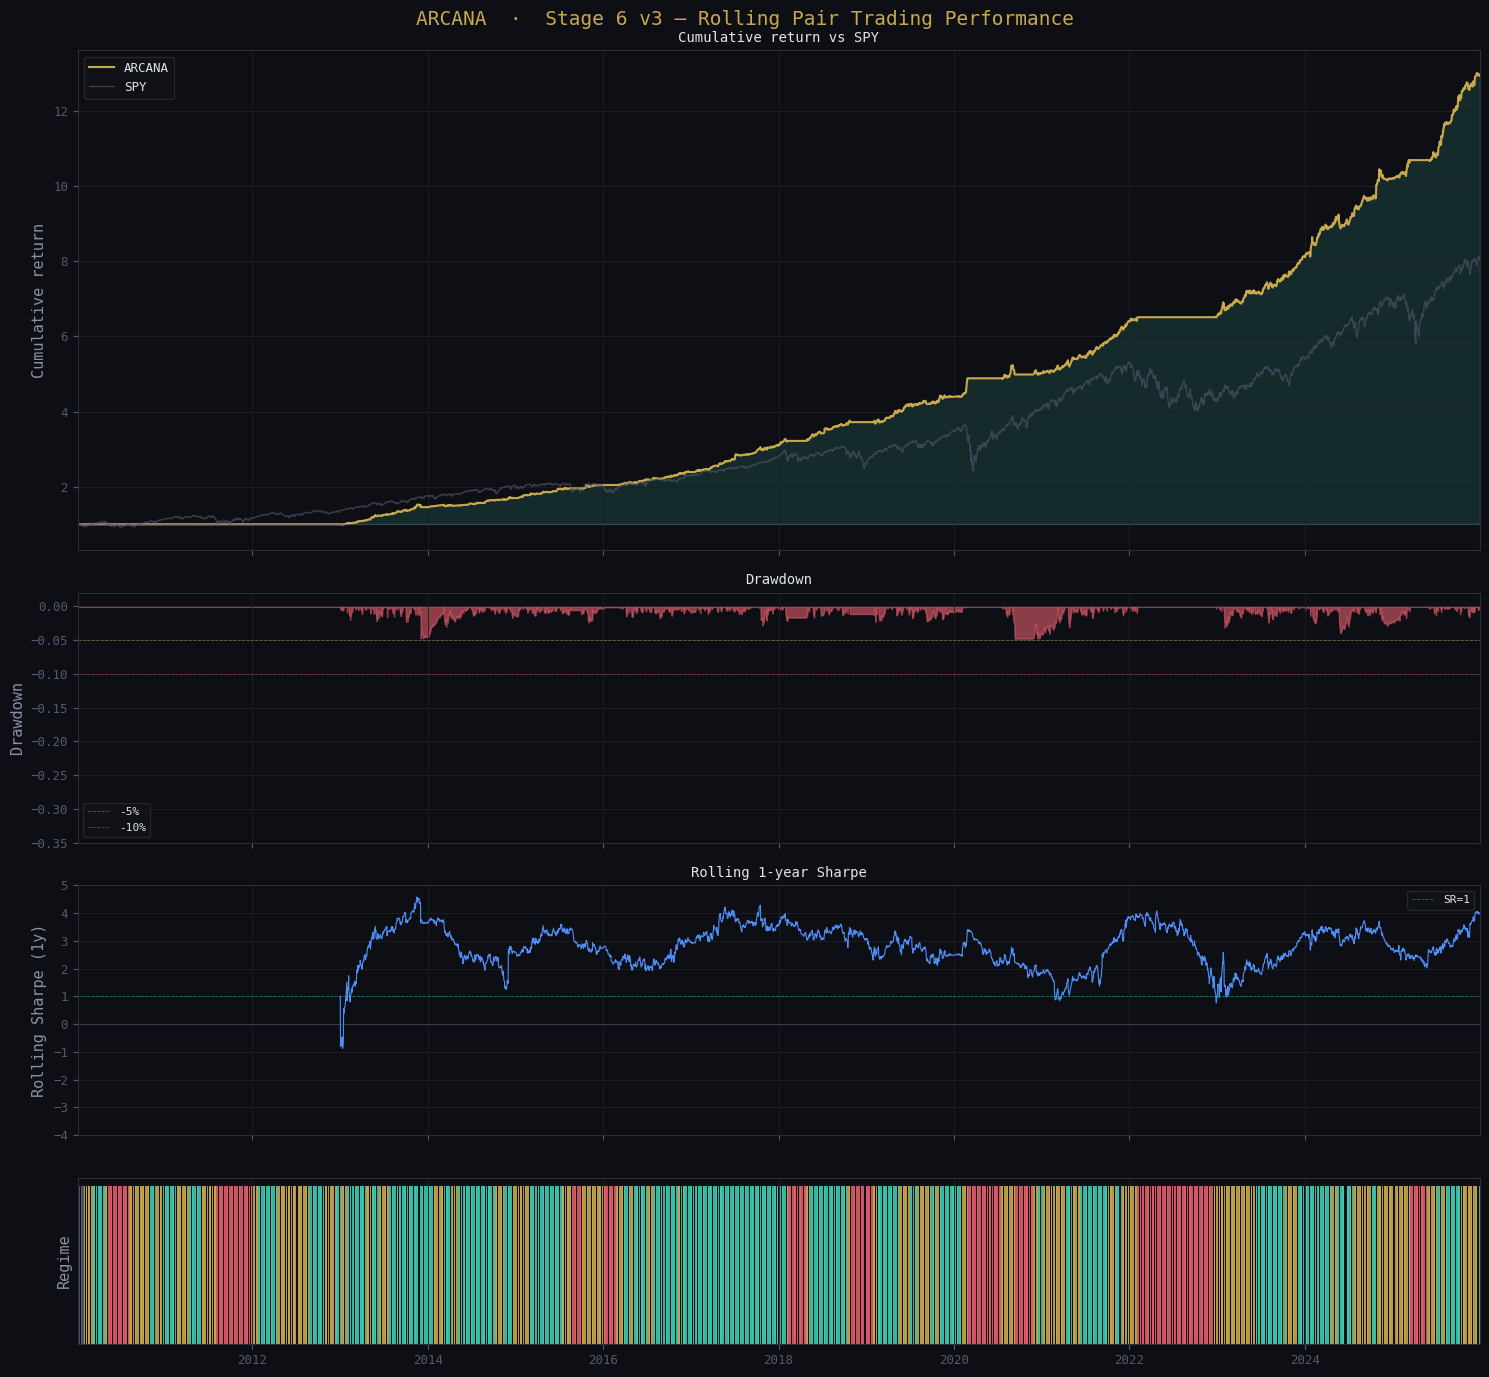

✓ viz_portfolio_performance.png


In [40]:
fig,axes=plt.subplots(4,1,figsize=(15,14),sharex=True,
                      gridspec_kw={'height_ratios':[3,1.5,1.5,1]})
fig.suptitle('ARCANA  ·  Stage 6 v3 — Rolling Pair Trading Performance',
             color=C_GOLD,fontsize=14)
roll_sharpe=port_ret.rolling(252).mean()/port_ret.rolling(252).std()*np.sqrt(252)

ax1=axes[0]
ax1.plot(cum_ret.index,cum_ret.values,color=C_GOLD,linewidth=1.5,label='ARCANA')
ax1.plot(spy_cum.index,spy_cum.values,color=C_GREY,linewidth=1.0,label='SPY',alpha=0.6)
ax1.fill_between(cum_ret.index,cum_ret.values,1,
                  where=cum_ret.values>=1,alpha=0.15,color=C_TEAL)
ax1.fill_between(cum_ret.index,cum_ret.values,1,
                  where=cum_ret.values<1,alpha=0.15,color=C_RED)
ax1.axhline(1,color=C_GREY,linewidth=0.4)
ax1.set_ylabel('Cumulative return');ax1.legend(fontsize=9)
ax1.set_title('Cumulative return vs SPY',color=C_WHITE,fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.set_xlim(common_dates[0],common_dates[-1])

ax2=axes[1]
ax2.fill_between(drawdown.index,drawdown.values,0,alpha=0.6,color=C_RED)
ax2.axhline(-0.05,color=C_GOLD,linewidth=0.6,linestyle='--',alpha=0.5,label='-5%')
ax2.axhline(-0.10,color=C_RED, linewidth=0.6,linestyle='--',alpha=0.5,label='-10%')
ax2.set_ylabel('Drawdown');ax2.set_ylim(-0.35,0.02)
ax2.set_title('Drawdown',color=C_WHITE,fontsize=10);ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax3=axes[2]
ax3.plot(roll_sharpe.index,roll_sharpe.values,color=C_BLUE,linewidth=0.8)
ax3.axhline(0,color=C_GREY,linewidth=0.4)
ax3.axhline(1,color=C_TEAL,linewidth=0.6,linestyle='--',alpha=0.5,label='SR=1')
ax3.set_ylabel('Rolling Sharpe (1y)');ax3.set_ylim(-4,5)
ax3.set_title('Rolling 1-year Sharpe',color=C_WHITE,fontsize=10)
ax3.legend(fontsize=8);ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax4=axes[3]
rl=regime_labels.reindex(common_dates)
ax4.bar(common_dates,np.ones(len(common_dates)),
        color=[REGIME_COLORS[int(r)] if not pd.isna(r) else C_GREY for r in rl.values],
        width=1.5,alpha=0.9)
ax4.set_yticks([]);ax4.set_ylabel('Regime')
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax4.set_xlim(common_dates[0],common_dates[-1])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'viz_portfolio_performance.png'),
            dpi=150,bbox_inches='tight',facecolor='#0d0f14')
plt.show();print('✓ viz_portfolio_performance.png')

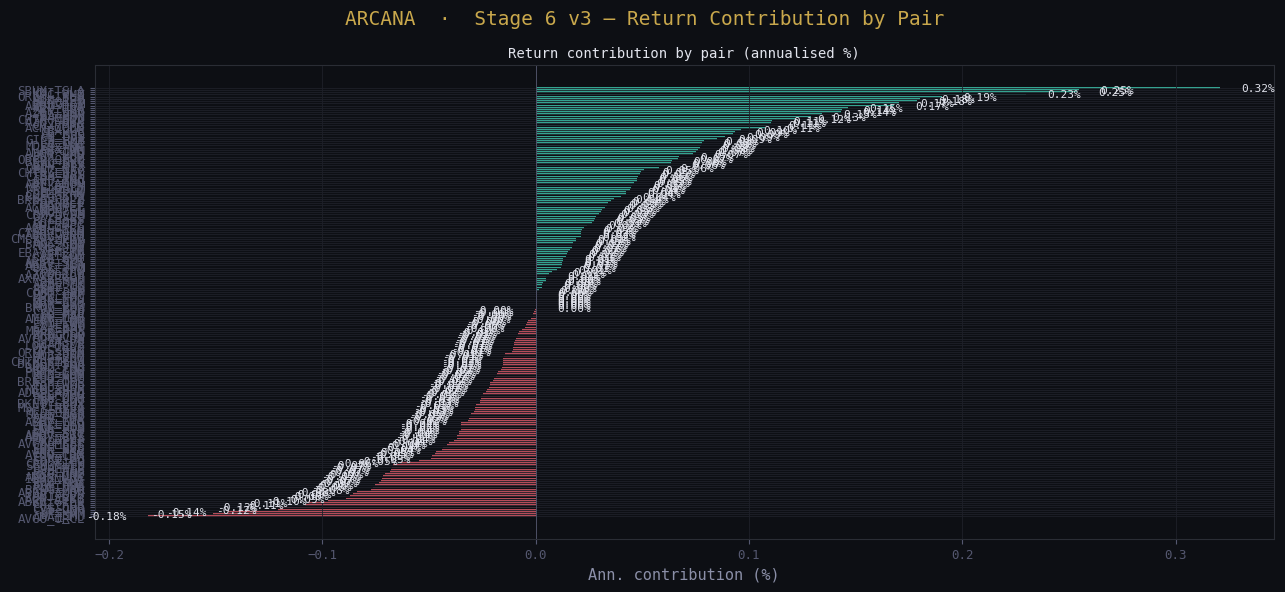

✓ viz_pair_contributions.png


In [41]:
# Pair contribution chart
fig,ax=plt.subplots(figsize=(13,6))
fig.suptitle('ARCANA  ·  Stage 6 v3 — Return Contribution by Pair',color=C_GOLD,fontsize=14)

pair_contribs={}
for pair in valid_pairs:
    tA=pair_info[pair]['tA'];tB=pair_info[pair]['tB']
    h=pair_info[pair]['h']
    if tA not in returns.columns or tB not in returns.columns: continue
    w_s=weight_log[pair] if pair in weight_log.columns else pd.Series(0.0,index=common_dates)
    ret_A=returns[tA].reindex(common_dates)
    ret_B=returns[tB].reindex(common_dates)
    pair_ret=(ret_A-h*ret_B)/(1+abs(h))
    contrib=(w_s.shift(1)*pair_ret).dropna()
    pair_contribs[pair]=contrib.mean()*252*100

contrib_s=pd.Series(pair_contribs).sort_values()
colors=[C_TEAL if v>=0 else C_RED for v in contrib_s.values]
ax.barh(contrib_s.index,contrib_s.values,color=colors,alpha=0.8)
ax.axvline(0,color=C_GREY,linewidth=0.6)
ax.set_xlabel('Ann. contribution (%)')
ax.set_title('Return contribution by pair (annualised %)',color=C_WHITE,fontsize=10)
for i,(pair,val) in enumerate(contrib_s.items()):
    ax.text(val+(0.01 if val>=0 else -0.01),i,f'{val:.2f}%',
            va='center',ha='left' if val>=0 else 'right',fontsize=8,color=C_WHITE)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'viz_pair_contributions.png'),
            dpi=150,bbox_inches='tight',facecolor='#0d0f14')
plt.show();print('✓ viz_pair_contributions.png')

---
## Step 7 · Summary

In [42]:
print('='*52)
print('  ARCANA — Stage 6 v3 Complete')
print('='*52)
print(f'  Pairs traded    : {len(valid_pairs)}')
print(f'  Date range      : {common_dates[0].date()} to {common_dates[-1].date()}')
print(f'  Ann. return     : {ann_ret*100:.2f}%')
print(f'  Sharpe          : {sharpe:.3f}')
print(f'  Max drawdown    : {max_dd*100:.2f}%')
print(f'  Win rate        : {win_rate*100:.1f}%')
print(f'  Portfolio beta  : {port_beta:.3f}')
for fname in ['portfolio_returns.csv','portfolio_weights.csv','portfolio_stats.csv']:
    fpath=os.path.join(OUTPUT_DIR,fname)
    size=os.path.getsize(fpath)/1024 if os.path.exists(fpath) else 0
    print(f'  {fname:<30} {size:>6.0f} KB')
print(f'\n  Next: Stage 7 — Risk Management')
print('='*52)

  ARCANA — Stage 6 v3 Complete
  Pairs traded    : 194
  Date range      : 2010-01-05 to 2025-12-31
  Ann. return     : 17.39%
  Sharpe          : 2.790
  Max drawdown    : -4.78%
  Win rate        : 58.7%
  Portfolio beta  : 0.009
  portfolio_returns.csv             109 KB
  portfolio_weights.csv            3440 KB
  portfolio_stats.csv                 0 KB

  Next: Stage 7 — Risk Management


In [43]:
# Check actual average exposure
gross_exposure = weight_log.abs().sum(axis=1)
print(f'Gross exposure stats:')
print(f'  Mean : {gross_exposure.mean()*100:.1f}%')
print(f'  Max  : {gross_exposure.max()*100:.1f}%')
print(f'  Min  : {gross_exposure.min()*100:.1f}%')
print(f'  % days fully deployed : {(gross_exposure>=0.9).mean()*100:.1f}%')

# Average open pairs per day
open_pairs = (weight_log.abs()>0).sum(axis=1)
print(f'\nOpen pairs stats:')
print(f'  Mean : {open_pairs.mean():.1f}')
print(f'  Max  : {open_pairs.max()}')
print(f'  % days with 0 pairs: {(open_pairs==0).mean()*100:.1f}%')

Gross exposure stats:
  Mean : 72.3%
  Max  : 300.0%
  Min  : 0.0%
  % days fully deployed : 44.5%

Open pairs stats:
  Mean : 5.4
  Max  : 11
  % days with 0 pairs: 34.0%
